# DP for EV Charging — Combined: Ideal Battery (Part A) + KiBaM (Part B)

This notebook unifies two stochastic dynamic-programming formulations of an EV-charging problem under uncertain electricity prices, then exports every input parameter and output to a single multi-sheet Excel workbook.

**Part A — Ideal battery.** The battery is a single perfectly-responsive bucket. The state is $(x_k, w_{k-1})$ where $x_k$ is the remaining energy demand (kWh) and $w_{k-1}$ is the most-recently-observed price.

**Part B — KiBaM (Kinetic Battery Model).** Two coupled tanks $(x_{1,k}, x_{2,k})$ — *available* and *bound* charge — capture realistic Li-ion behavior including CC-CV tapering and the recovery effect.

**Shared price model** in both parts:
$$w_k \mid w_{k-1} \;\sim\; \text{Uniform}\!\big[\max(0,\,2w_{k-1}-K-\Delta),\; K+\Delta\big],\qquad \mathbb E[w_k\mid w_{k-1}] = w_{k-1}$$

**Shared Bellman recursion** (state dim differs):
$$J_k(s_k) \;=\; \min_{u_k}\;\mathbb{E}_{w_k\mid w_{k-1}}\!\Big[w_k u_k + J_{k+1}(s_{k+1})\Big]$$

**Function-naming convention.** The ideal-case functions keep their original names (`price_quadrature`, `init_J_policy`, `solve_dp`, `get_initial`, `simulate_sample_path`); the KiBaM versions are suffixed with `_kibam` (`solve_dp_kibam`, etc.). KiBaM-specific helpers are `interp_3d` and `kibam_step`.

## 0.1 Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401  (registers 3D projection)
from numpy.polynomial.legendre import leggauss
import os
from datetime import datetime

## 0.2 Output File Path

All outputs (parameters, sensitivity tables, sample paths, recovery data, comparison) are written to a single `.xlsx`. Edit `excel_path` if you want a different location.

In [2]:
excel_path = 'DP_EV_Combined_Results.xlsx'
print(f"Excel output will be written to: {os.path.abspath(excel_path)}")

Excel output will be written to: c:\Users\dhrub\Downloads\DP_EV_Combined_Results.xlsx


# Part A — Ideal Battery

## A.1 Theory Recap (Ideal Case)

**State:** $s_k = (x_k, w_{k-1})$ where $x_k$ is remaining demand (kWh), $w_{k-1}$ is last observed price.

**Dynamics (deterministic):** $x_{k+1} = x_k - u_k$.

**Control constraint:** $0 \le u_k \le \min(x_k,\, P_{\max}\Delta t)$.

**Stage cost:** $g_k = u_k w_k$. **Terminal cost:** $g_N = K_T\, x_N$.

**Bellman equation:**
$$J_k(x_k, w_{k-1}) \;=\; \min_{u_k}\;\mathbb{E}_{w_k\mid w_{k-1}}\!\Big[u_k w_k + J_{k+1}(x_k - u_k,\, w_k)\Big]$$

**Boundary:** $J_N(x_N, w_{N-1}) = K_T x_N$.

## A.2 Parameters (Ideal)

In [3]:
# ---------- Time horizon ----------
N = 8
Delta_t = 1.0

# ---------- Battery (ideal) ----------
E_max = 40.0

# ---------- Power limit ----------
P_max = 7.0
u_max_physical = P_max * Delta_t

# ---------- Price model ----------
K = 0.30
w_initial = 0.30

# ---------- Initial state (ideal) ----------
x0 = E_max          # full demand at start

# ---------- Sensitivity sweep (shared between Part A and Part B) ----------
K_T_values   = [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]    
Delta_values = [0.05, 0.10, 0.20]                     

# Representative case used for plots
K_T_rep   = 0.5
Delta_rep = 0.10

# ---------- Discretization (ideal) ----------
Nx = 31
Nw = 31
Nu = 31
num_price_quad = 5

print(f"[Ideal] State grid:   Nx={Nx}, Nw={Nw}  ->  {Nx*Nw} (x,w) pairs / step")
print(f"[Ideal] Control grid: Nu={Nu}")
print(f"[Ideal] Quadrature:   {num_price_quad} GL points")

[Ideal] State grid:   Nx=31, Nw=31  ->  961 (x,w) pairs / step
[Ideal] Control grid: Nu=31
[Ideal] Quadrature:   5 GL points


## A.3 State Grids (Ideal)

In [4]:
x_grid = np.linspace(0, E_max, Nx)

Delta_max = max(Delta_values)
w_grid    = np.linspace(0.0, K + Delta_max, Nw)

print(f"x_grid: {Nx} pts in [{x_grid[0]:.2f}, {x_grid[-1]:.2f}]")
print(f"w_grid: {Nw} pts in [{w_grid[0]:.2f}, {w_grid[-1]:.2f}]")

x_grid: 31 pts in [0.00, 40.00]
w_grid: 31 pts in [0.00, 0.50]


## A.4 Bilinear Interpolation `interp_2d`

When $J_{k+1}$ is evaluated at off-grid $(x, w)$ we blend the four surrounding corners:
$$\hat J(x,w) = (1-t_x)(1-t_w)J_{00} + t_x(1-t_w)J_{10} + (1-t_x)t_w J_{01} + t_x t_w J_{11}$$

In [5]:
def interp_2d(J_next, x_val, w_val, x_grid, w_grid):
    x_val = np.clip(x_val, x_grid[0], x_grid[-1])
    w_val = np.clip(w_val, w_grid[0], w_grid[-1])

    ix = np.clip(np.searchsorted(x_grid, x_val) - 1, 0, len(x_grid) - 2)
    iw = np.clip(np.searchsorted(w_grid, w_val) - 1, 0, len(w_grid) - 2)

    x0g, x1g = x_grid[ix], x_grid[ix+1]
    w0g, w1g = w_grid[iw], w_grid[iw+1]

    tx = (x_val - x0g) / (x1g - x0g)
    tw = (w_val - w0g) / (w1g - w0g)

    J00 = J_next[ix,   iw  ]
    J10 = J_next[ix+1, iw  ]
    J01 = J_next[ix,   iw+1]
    J11 = J_next[ix+1, iw+1]

    return ((1-tx)*(1-tw)*J00 + tx*(1-tw)*J10 +
            (1-tx)*tw*J01    + tx*tw*J11)

## A.5 Price Quadrature `price_quadrature` (Gauss-Legendre)

For $f$ smooth, Gauss-Legendre with $N_q$ points exactly integrates polynomials of degree $\le 2N_q - 1$.

$$\mathbb{E}_{w \sim U[a,b]}[f(w)] \;\approx\; \sum_{i=1}^{N_q} \tilde\omega_i\, f(w_i)$$

with $a = \max(0,\, 2w_{k-1}-K-\Delta)$ and $b = K + \Delta$, normalized so $\sum_i \tilde\omega_i = 1$.

In [6]:
def price_quadrature(w_prev, K, Delta, num_points=5, allow_negative_prices=False):
    a = 2 * w_prev - K - Delta
    b = K + Delta
    if not allow_negative_prices:
        a = max(0.0, a)
    if abs(b - a) < 1e-10:
        return np.array([a]), np.array([1.0])
    xi, wi  = leggauss(num_points)
    nodes   = 0.5 * (b - a) * xi + 0.5 * (a + b)
    weights = 0.5 * (b - a) * wi
    weights = weights / (b - a)
    return nodes, weights

## A.6 Initialization `init_J_policy`

Boundary condition: $J_N(x_N, w_{N-1}) = K_T x_N$ (independent of $w_{N-1}$).

In [7]:
def init_J_policy(K_T):
    J      = np.zeros((N + 1, Nx, Nw))
    policy = np.zeros((N,     Nx, Nw))
    for ix, x in enumerate(x_grid):
        J[N, ix, :] = K_T * x
    return J, policy

## A.7 Backward Induction `solve_dp`

Discrete approximation of:
$$J_k(x, w_{k-1}) \;=\; \min_{u\in[0,\,\min(x,u_{\max})]} \;\sum_{i=1}^{N_q} \tilde\omega_i\Big[w_i u + J_{k+1}(x-u,\, w_i)\Big]$$

In [8]:
def solve_dp(K_T, Delta):
    J, policy = init_J_policy(K_T)

    quad_nodes, quad_weights = [], []
    for w_prev in w_grid:
        nodes, weights = price_quadrature(w_prev, K, Delta, num_price_quad)
        quad_nodes.append(nodes)
        quad_weights.append(weights)

    u_grid_full = np.linspace(0, u_max_physical, Nu)

    for k in reversed(range(N)):
        for ix, x in enumerate(x_grid):
            for iw, w_prev in enumerate(w_grid):

                u_upper = min(x, u_max_physical)
                if u_upper <= 1e-12:
                    continue

                u_grid_local = u_grid_full[u_grid_full <= u_upper]

                best_cost, best_u = np.inf, 0.0
                for u in u_grid_local:
                    x_next = x - u
                    cost = 0.0
                    for w_next, wt in zip(quad_nodes[iw], quad_weights[iw]):
                        if k == N - 1:
                            future = K_T * x_next
                        else:
                            future = interp_2d(J[k+1], x_next, w_next,
                                               x_grid, w_grid)
                        cost += wt * (w_next * u + future)
                    if cost < best_cost:
                        best_cost, best_u = cost, u

                J[k, ix, iw]      = best_cost
                policy[k, ix, iw] = best_u

    return J, policy

## A.8 Initial-Value Extraction `get_initial`

In [9]:
def get_initial(J, policy):
    ix0 = np.argmin(np.abs(x_grid - x0))
    iw0 = np.argmin(np.abs(w_grid - w_initial))
    return policy[0, ix0, iw0], J[0, ix0, iw0]

## A.9 Sensitivity Sweep over $(K_T, \Delta)$ — Ideal

We loop over $4 \times 3 = 12$ parameter pairs and store $u_0^*$ and $J_0^*$ for each. We *also* capture $(J, \text{policy})$ at the representative case for the plots below — this avoids re-solving.

In [ ]:
ideal_results = []
J_ideal, policy_ideal = None, None
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

for K_T in K_T_values:
    for Delta in Delta_values:
        print(f"[Ideal] solving K_T={K_T}, Delta={Delta} ...")
        J, policy = solve_dp(K_T, Delta)
        u0, J0 = get_initial(J, policy)
        ideal_results.append({
            'timestamp': timestamp,
            'model': 'Ideal',
            'K_T': K_T,
            'Delta': Delta,
            'u0_star': u0,
            'J0_star': J0,
        })
        if np.isclose(K_T, K_T_rep) and np.isclose(Delta, Delta_rep):
            J_ideal, policy_ideal = J, policy

df_ideal_sens = pd.DataFrame(ideal_results)
print("\n[Ideal] sensitivity table:")
print(df_ideal_sens)

[Ideal] solving K_T=0.1, Delta=0.05 ...
[Ideal] solving K_T=0.1, Delta=0.1 ...
[Ideal] solving K_T=0.1, Delta=0.2 ...
[Ideal] solving K_T=0.2, Delta=0.05 ...


## A.10 Policy Heatmaps — Ideal (k = 0, 3, 7)

Each heatmap shows $u_k^*(x_k, w_{k-1})$ at the representative $(K_T, \Delta) = (0.5, 0.10)$. Expected qualitative feature: a **vertical threshold** near $w \approx K_T$ (charge fully on the left, do nothing on the right).

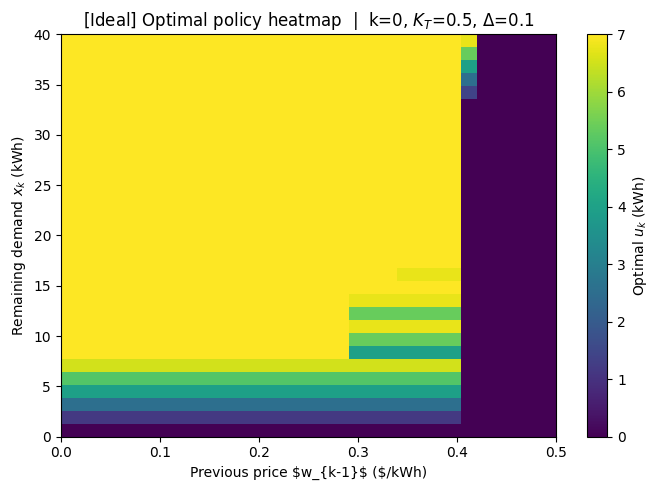

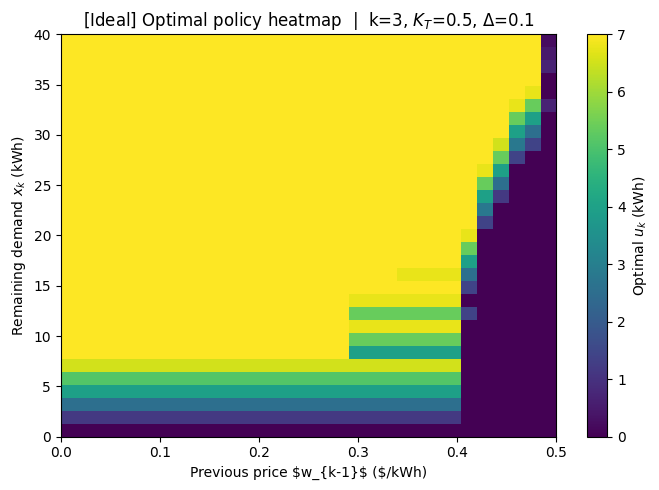

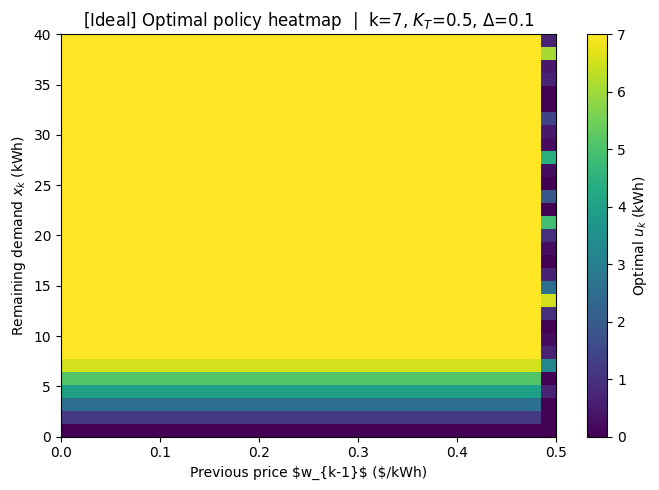

In [ ]:
for k_plot in [0, 3, 7]:
    plt.figure(figsize=(7, 5))
    plt.imshow(policy_ideal[k_plot, :, :],
               origin='lower', aspect='auto',
               extent=[w_grid[0], w_grid[-1], x_grid[0], x_grid[-1]])
    plt.colorbar(label='Optimal $u_k$ (kWh)')
    plt.xlabel('Previous price $w_{k-1}$ ($/kWh)')
    plt.ylabel('Remaining demand $x_k$ (kWh)')
    plt.title(f'[Ideal] Optimal policy heatmap  |  k={k_plot}, '
              f'$K_T$={K_T_rep}, $\\Delta$={Delta_rep}')
    plt.tight_layout()
    plt.show()

## A.11 Sample-Path Simulation — Ideal

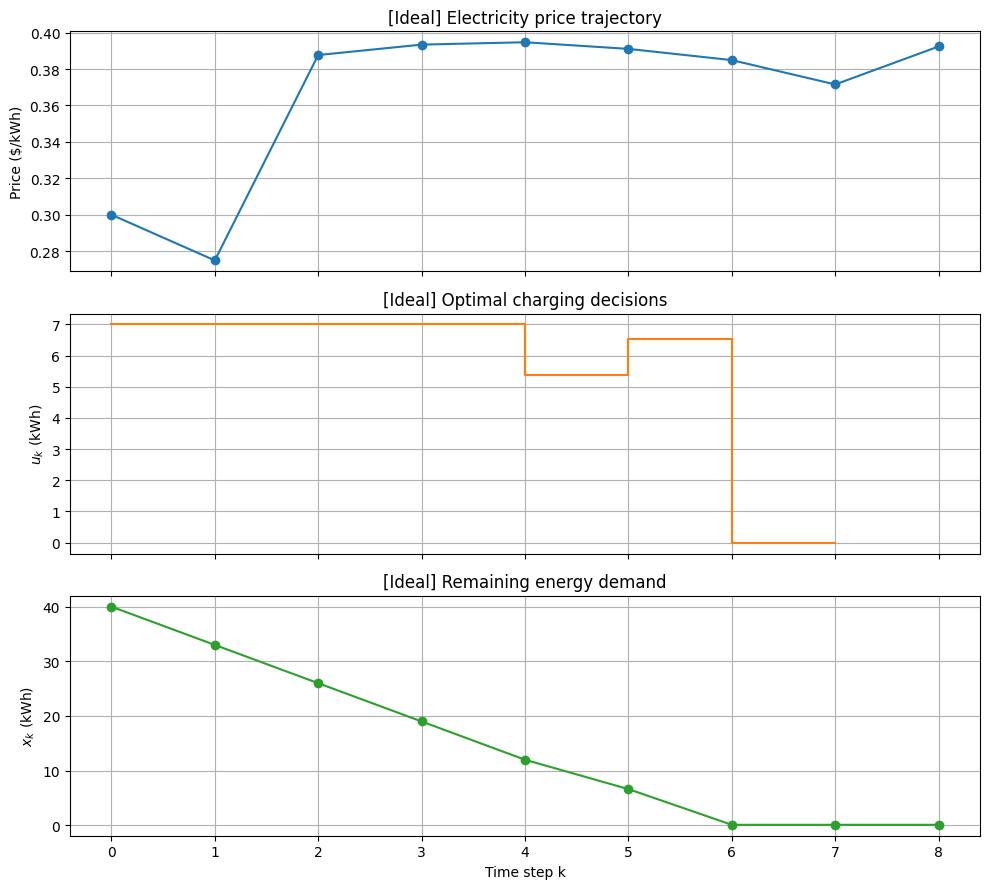

In [ ]:
def simulate_sample_path(policy, K, Delta, seed=42):
    np.random.seed(seed)
    x, w_prev = x0, w_initial
    x_traj, w_traj, u_traj = [x], [w_prev], []

    for k in range(N):
        ix = np.argmin(np.abs(x_grid - x))
        iw = np.argmin(np.abs(w_grid - w_prev))
        u  = policy[k, ix, iw]
        u  = min(u, x, u_max_physical)
        x  = x - u

        a = max(0.0, 2 * w_prev - K - Delta)
        b = K + Delta
        w_next = np.random.uniform(a, b)

        u_traj.append(u)
        x_traj.append(x)
        w_traj.append(w_next)
        w_prev = w_next

    return np.array(x_traj), np.array(w_traj), np.array(u_traj)


x_traj_A, w_traj_A, u_traj_A = simulate_sample_path(
    policy_ideal, K, Delta_rep)

time = np.arange(N + 1)

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(time, w_traj_A, marker='o')
axes[0].set_ylabel('Price ($/kWh)')
axes[0].set_title('[Ideal] Electricity price trajectory')
axes[0].grid()

axes[1].step(range(N), u_traj_A, where='post', color='tab:orange')
axes[1].set_ylabel('$u_k$ (kWh)')
axes[1].set_title('[Ideal] Optimal charging decisions')
axes[1].grid()

axes[2].plot(time, x_traj_A, marker='o', color='tab:green')
axes[2].set_xlabel('Time step k')
axes[2].set_ylabel('$x_k$ (kWh)')
axes[2].set_title('[Ideal] Remaining energy demand')
axes[2].grid()

plt.tight_layout()
plt.show()

## A.12 Value Function $J_1(x_1, w_0)$ — Ideal

For three values of $w_0$, plot $J_1$ vs $x_1$. Theory predicts piecewise-linear curves with slope $\min(w_0, K_T)$ for $x_1 \le u_{\max}$.

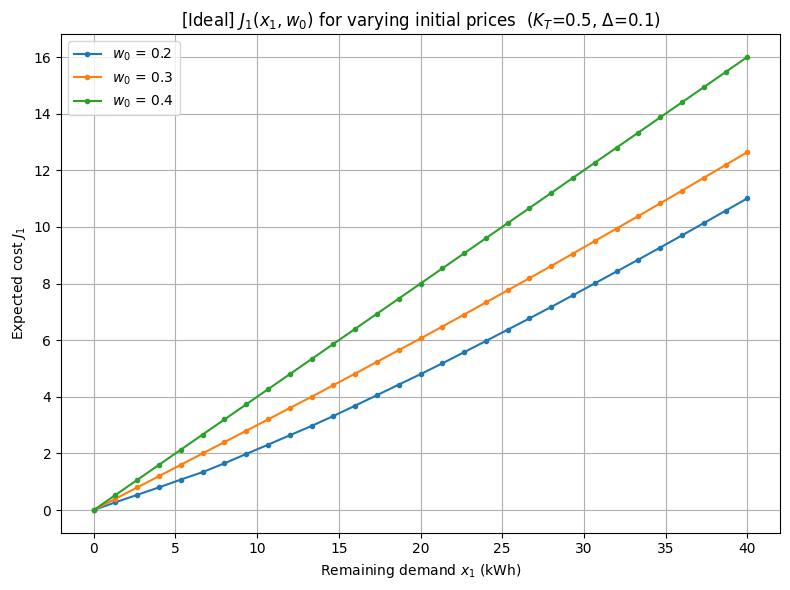

In [ ]:
w0_values = [0.2, 0.3, 0.4]
plt.figure(figsize=(8, 6))
for w0 in w0_values:
    iw0 = np.argmin(np.abs(w_grid - w0))
    J1_vals = J_ideal[1, :, iw0]
    plt.plot(x_grid, J1_vals, marker='.', label=f'$w_0$ = {w0}')
plt.xlabel('Remaining demand $x_1$ (kWh)')
plt.ylabel('Expected cost $J_1$')
plt.title(f'[Ideal] $J_1(x_1, w_0)$ for varying initial prices  '
          f'($K_T$={K_T_rep}, $\\Delta$={Delta_rep})')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## A.13 Verification: $\Delta \to 0$ — Ideal

When the price spread vanishes, $w_k = w_{k-1}$ deterministically. The policy should collapse to a clean two-region partition: charge max if $w_0 < K_T$, do nothing otherwise.

[Ideal][Verification] Re-solving with Delta = 0.0001 ...


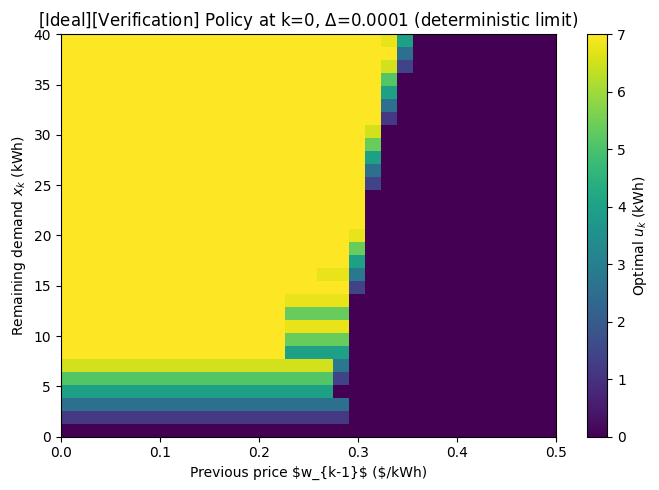

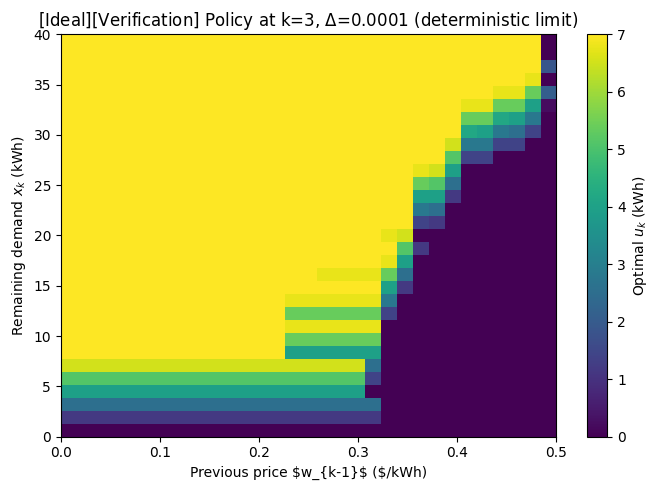

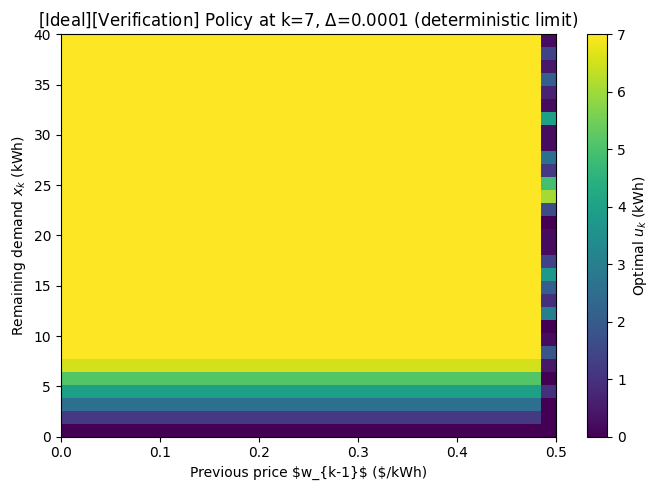

In [ ]:
K_T_verify   = 0.5
Delta_verify = 1e-4
print(f"[Ideal][Verification] Re-solving with Delta = {Delta_verify} ...")
J_verify, policy_verify = solve_dp(K_T_verify, Delta_verify)

for k_plot in [0, 3, 7]:
    plt.figure(figsize=(7, 5))
    plt.imshow(policy_verify[k_plot, :, :],
               origin='lower', aspect='auto',
               extent=[w_grid[0], w_grid[-1], x_grid[0], x_grid[-1]])
    plt.colorbar(label='Optimal $u_k$ (kWh)')
    plt.xlabel('Previous price $w_{k-1}$ ($/kWh)')
    plt.ylabel('Remaining demand $x_k$ (kWh)')
    plt.title(f'[Ideal][Verification] Policy at k={k_plot}, '
              f'$\\Delta$={Delta_verify} (deterministic limit)')
    plt.tight_layout()
    plt.show()

# Part B — KiBaM Battery

## B.1 Theory Recap (KiBaM)

**State:** $s_k = (x_{1,k},\, x_{2,k},\, w_{k-1})$.

**Dynamics (forward Euler):**
$$x_{1,k+1} = x_{1,k} + u_k - \alpha\,\Delta t\,(x_{1,k} - x_{2,k})$$
$$x_{2,k+1} = x_{2,k} + \alpha\,\Delta t\,(x_{1,k} - x_{2,k})$$

Adding gives $x_{1,k+1} + x_{2,k+1} = x_{1,k} + x_{2,k} + u_k$ (energy conserved).

**Control constraint** (CC-CV emerges naturally):
$$0 \le u_k \le \min\!\Big(P_{\max}\Delta t,\; \alpha(x_{1,\max} - x_{2,k})\Big)$$

**Stage cost:** $g_k = w_k u_k$.  
**Terminal cost:** $g_N = K_T\big[(x_{1,\max}+x_{2,\max}) - x_{1,N} - x_{2,N}\big]$.

**Bellman:**
$$J_k(x_1, x_2, w_{k-1}) = \min_{u_k}\;\mathbb{E}_{w_k\mid w_{k-1}}\!\Big[w_k u_k + J_{k+1}(x_{1,k+1},\, x_{2,k+1},\, w_k)\Big]$$

## B.2 Parameters (KiBaM)

We pick $x_{1,\max} = x_{2,\max} = 20$ kWh so the **total** capacity matches the ideal case (40 kWh). The discretization is **smaller** because the state is now 3-D.

In [ ]:
# ---------- Battery (KiBaM-specific) ----------
x1_max = 20.0
x2_max = 20.0
alpha  = 0.30          # KiBaM rate constant (1/hr)

# ---------- Initial state (KiBaM) ----------
x1_0 = 0.0
x2_0 = 0.0

# ---------- Discretization (KiBaM) ----------
Nx1 = 11
Nx2 = 11
Nw_kibam              = 9
Nu_kibam              = 9
num_price_quad_kibam  = 3

print(f"[KiBaM] State grid:   Nx1={Nx1}, Nx2={Nx2}, Nw={Nw_kibam}  "
      f"->  {Nx1*Nx2*Nw_kibam} states / step")
print(f"[KiBaM] Control grid: Nu={Nu_kibam}")
print(f"[KiBaM] Quadrature:   {num_price_quad_kibam} GL points")

[KiBaM] State grid:   Nx1=11, Nx2=11, Nw=9  ->  1089 states / step
[KiBaM] Control grid: Nu=9
[KiBaM] Quadrature:   3 GL points


## B.3 State Grids (KiBaM)

In [ ]:
x1_grid      = np.linspace(0.0, x1_max, Nx1)
x2_grid      = np.linspace(0.0, x2_max, Nx2)
w_grid_kibam = np.linspace(0.0, K + Delta_max, Nw_kibam)

print(f"x1_grid:      {Nx1} pts in [{x1_grid[0]:.2f}, {x1_grid[-1]:.2f}]")
print(f"x2_grid:      {Nx2} pts in [{x2_grid[0]:.2f}, {x2_grid[-1]:.2f}]")
print(f"w_grid_kibam: {Nw_kibam} pts in "
      f"[{w_grid_kibam[0]:.2f}, {w_grid_kibam[-1]:.2f}]")

x1_grid:      11 pts in [0.00, 20.00]
x2_grid:      11 pts in [0.00, 20.00]
w_grid_kibam: 9 pts in [0.00, 0.50]


## B.4 Trilinear Interpolation `interp_3d`

3-D extension of `interp_2d` — weighted average over the 8 corners of the surrounding box.

In [ ]:
def interp_3d(J_next, x1_val, x2_val, w_val, x1_grid, x2_grid, w_grid):
    x1_val = np.clip(x1_val, x1_grid[0], x1_grid[-1])
    x2_val = np.clip(x2_val, x2_grid[0], x2_grid[-1])
    w_val  = np.clip(w_val,  w_grid[0],  w_grid[-1])

    i1 = np.clip(np.searchsorted(x1_grid, x1_val) - 1, 0, len(x1_grid) - 2)
    i2 = np.clip(np.searchsorted(x2_grid, x2_val) - 1, 0, len(x2_grid) - 2)
    iw = np.clip(np.searchsorted(w_grid,  w_val)  - 1, 0, len(w_grid)  - 2)

    t1 = (x1_val - x1_grid[i1]) / (x1_grid[i1+1] - x1_grid[i1])
    t2 = (x2_val - x2_grid[i2]) / (x2_grid[i2+1] - x2_grid[i2])
    tw = (w_val  - w_grid[iw])  / (w_grid[iw+1]  - w_grid[iw])

    J000 = J_next[i1,   i2,   iw  ]
    J100 = J_next[i1+1, i2,   iw  ]
    J010 = J_next[i1,   i2+1, iw  ]
    J110 = J_next[i1+1, i2+1, iw  ]
    J001 = J_next[i1,   i2,   iw+1]
    J101 = J_next[i1+1, i2,   iw+1]
    J011 = J_next[i1,   i2+1, iw+1]
    J111 = J_next[i1+1, i2+1, iw+1]

    return ((1-t1)*(1-t2)*(1-tw)*J000 + t1*(1-t2)*(1-tw)*J100 +
            (1-t1)*t2*(1-tw)*J010    + t1*t2*(1-tw)*J110    +
            (1-t1)*(1-t2)*tw*J001    + t1*(1-t2)*tw*J101    +
            (1-t1)*t2*tw*J011        + t1*t2*tw*J111)

## B.5 Price Quadrature `price_quadrature_kibam`

Functionally identical to Part A — the price model doesn't change. Renamed only to avoid global shadowing in the combined notebook.

In [ ]:
def price_quadrature_kibam(w_prev, K, Delta, num_points=5,
                            allow_negative_prices=False):
    a = 2 * w_prev - K - Delta
    b = K + Delta
    if not allow_negative_prices:
        a = max(0.0, a)
    if abs(b - a) < 1e-10:
        return np.array([a]), np.array([1.0])
    xi, wi  = leggauss(num_points)
    nodes   = 0.5 * (b - a) * xi + 0.5 * (a + b)
    weights = 0.5 * (b - a) * wi
    weights = weights / (b - a)
    return nodes, weights

## B.6 KiBaM Step `kibam_step`

One forward-Euler update. Flow $\alpha\Delta t(x_1 - x_2)$ moves charge $x_1 \to x_2$ when $x_1 > x_2$, **reverses** when $x_2 > x_1$ (this reversal is the recovery effect).

In [ ]:
def kibam_step(x1, x2, u, alpha, Delta_t):
    flow    = alpha * Delta_t * (x1 - x2)
    x1_next = x1 + u - flow
    x2_next = x2 + flow
    return x1_next, x2_next

## B.7 Initialization `init_J_policy_kibam`

Boundary condition: $J_N = K_T[(x_{1,\max}+x_{2,\max}) - x_1 - x_2]$ (independent of $w$).

In [ ]:
def init_J_policy_kibam(K_T):
    J      = np.zeros((N + 1, Nx1, Nx2, Nw_kibam))
    policy = np.zeros((N,     Nx1, Nx2, Nw_kibam))
    for i1, x1 in enumerate(x1_grid):
        for i2, x2 in enumerate(x2_grid):
            J[N, i1, i2, :] = K_T * ((x1_max + x2_max) - x1 - x2)
    return J, policy

## B.8 Backward Induction `solve_dp_kibam`

3-D state version of the Bellman recursion, with the KiBaM-aware control upper bound.

In [ ]:
def solve_dp_kibam(K_T, Delta):
    J, policy = init_J_policy_kibam(K_T)

    quad_nodes, quad_weights = [], []
    for w_prev in w_grid_kibam:
        nodes, weights = price_quadrature_kibam(
            w_prev, K, Delta, num_price_quad_kibam)
        quad_nodes.append(nodes)
        quad_weights.append(weights)

    u_grid_full = np.linspace(0.0, u_max_physical, Nu_kibam)

    for k in reversed(range(N)):
        for i1, x1 in enumerate(x1_grid):
            for i2, x2 in enumerate(x2_grid):

                u_upper = min(u_max_physical, alpha * (x1_max - x2))
                u_upper = max(u_upper, 0.0)
                u_grid_local = u_grid_full[u_grid_full <= u_upper]
                if len(u_grid_local) == 0:
                    u_grid_local = np.array([0.0])

                for iw, w_prev in enumerate(w_grid_kibam):
                    best_cost, best_u = np.inf, 0.0
                    for u in u_grid_local:
                        x1_next, x2_next = kibam_step(x1, x2, u, alpha, Delta_t)
                        cost = 0.0
                        for w_next, wt in zip(quad_nodes[iw], quad_weights[iw]):
                            if k == N - 1:
                                future = K_T * ((x1_max + x2_max)
                                                - x1_next - x2_next)
                            else:
                                future = interp_3d(J[k+1], x1_next, x2_next,
                                                   w_next,
                                                   x1_grid, x2_grid,
                                                   w_grid_kibam)
                            cost += wt * (w_next * u + future)
                        if cost < best_cost:
                            best_cost, best_u = cost, u

                    J[k, i1, i2, iw]      = best_cost
                    policy[k, i1, i2, iw] = best_u

    return J, policy

## B.9 Initial-Value Extraction `get_initial_kibam`

In [ ]:
def get_initial_kibam(J, policy):
    i1_0 = np.argmin(np.abs(x1_grid      - x1_0))
    i2_0 = np.argmin(np.abs(x2_grid      - x2_0))
    iw_0 = np.argmin(np.abs(w_grid_kibam - w_initial))
    return policy[0, i1_0, i2_0, iw_0], J[0, i1_0, i2_0, iw_0]

## B.10 Sensitivity Sweep over $(K_T, \Delta)$ — KiBaM

In [ ]:
kibam_results = []
J_kibam, policy_kibam = None, None

for K_T in K_T_values:
    for Delta in Delta_values:
        print(f"[KiBaM] solving K_T={K_T}, Delta={Delta} ...")
        J, policy = solve_dp_kibam(K_T, Delta)
        u0, J0 = get_initial_kibam(J, policy)
        kibam_results.append({
            'timestamp': timestamp,
            'model': 'KiBaM',
            'K_T': K_T,
            'Delta': Delta,
            'u0_star': u0,
            'J0_star': J0,
        })
        if np.isclose(K_T, K_T_rep) and np.isclose(Delta, Delta_rep):
            J_kibam, policy_kibam = J, policy

df_kibam_sens = pd.DataFrame(kibam_results)
print("\n[KiBaM] sensitivity table:")
print(df_kibam_sens)

[KiBaM] solving K_T=0.1, Delta=0.05 ...
[KiBaM] solving K_T=0.1, Delta=0.1 ...
[KiBaM] solving K_T=0.1, Delta=0.2 ...
[KiBaM] solving K_T=0.2, Delta=0.05 ...
[KiBaM] solving K_T=0.2, Delta=0.1 ...
[KiBaM] solving K_T=0.2, Delta=0.2 ...
[KiBaM] solving K_T=0.3, Delta=0.05 ...
[KiBaM] solving K_T=0.3, Delta=0.1 ...
[KiBaM] solving K_T=0.3, Delta=0.2 ...
[KiBaM] solving K_T=0.4, Delta=0.05 ...
[KiBaM] solving K_T=0.4, Delta=0.1 ...
[KiBaM] solving K_T=0.4, Delta=0.2 ...
[KiBaM] solving K_T=0.5, Delta=0.05 ...
[KiBaM] solving K_T=0.5, Delta=0.1 ...
[KiBaM] solving K_T=0.5, Delta=0.2 ...
[KiBaM] solving K_T=0.7, Delta=0.05 ...
[KiBaM] solving K_T=0.7, Delta=0.1 ...
[KiBaM] solving K_T=0.7, Delta=0.2 ...
[KiBaM] solving K_T=1.0, Delta=0.05 ...
[KiBaM] solving K_T=1.0, Delta=0.1 ...
[KiBaM] solving K_T=1.0, Delta=0.2 ...

[KiBaM] sensitivity table:
              timestamp  model  K_T  Delta  u0_star    J0_star
0   2026-05-01 19:47:46  KiBaM  0.1   0.05     0.00   4.000000
1   2026-05-01 19:47

## B.11 Policy Heatmaps — KiBaM (k = 0, 3, 7)

We slice the 3-D policy at a representative $x_2$ (mid-grid) and plot $u_k^*(x_1, w_{k-1})$.

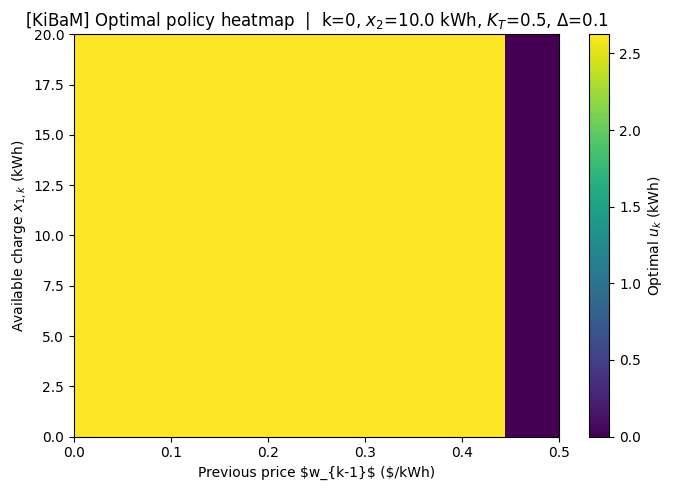

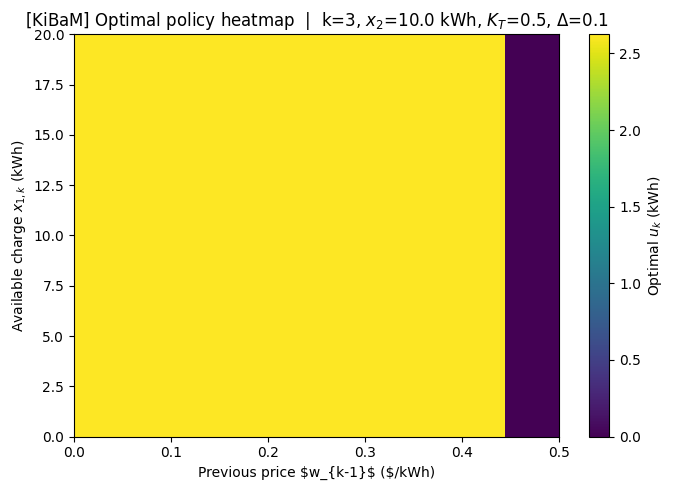

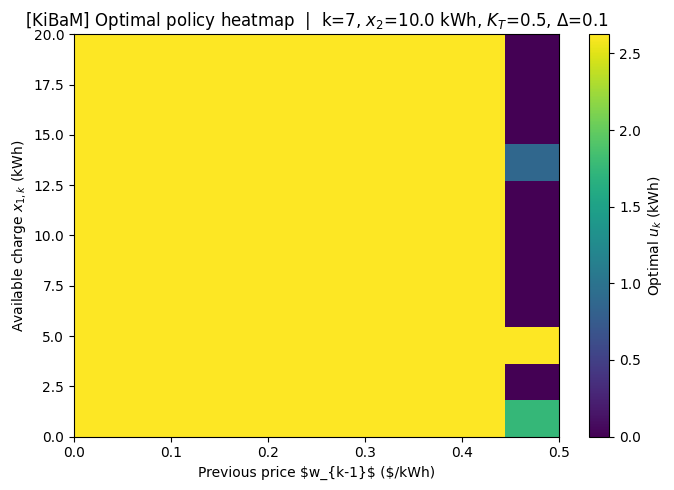

In [ ]:
i2_fix = Nx2 // 2
x2_fix = x2_grid[i2_fix]

for k_plot in [0, 3, 7]:
    plt.figure(figsize=(7, 5))
    plt.imshow(policy_kibam[k_plot, :, i2_fix, :],
               origin='lower', aspect='auto',
               extent=[w_grid_kibam[0], w_grid_kibam[-1],
                       x1_grid[0], x1_grid[-1]])
    plt.colorbar(label='Optimal $u_k$ (kWh)')
    plt.xlabel('Previous price $w_{k-1}$ ($/kWh)')
    plt.ylabel('Available charge $x_{1,k}$ (kWh)')
    plt.title(f'[KiBaM] Optimal policy heatmap  |  k={k_plot}, '
              f'$x_2$={x2_fix:.1f} kWh, '
              f'$K_T$={K_T_rep}, $\\Delta$={Delta_rep}')
    plt.tight_layout()
    plt.show()

## B.12 3-D Policy Surface $u_k^*(x_1, x_2)$ — KiBaM

A view that has no analog in the ideal case. CC-CV tapering should appear as the surface bending downward as $x_2 \to x_{1,\max}$.

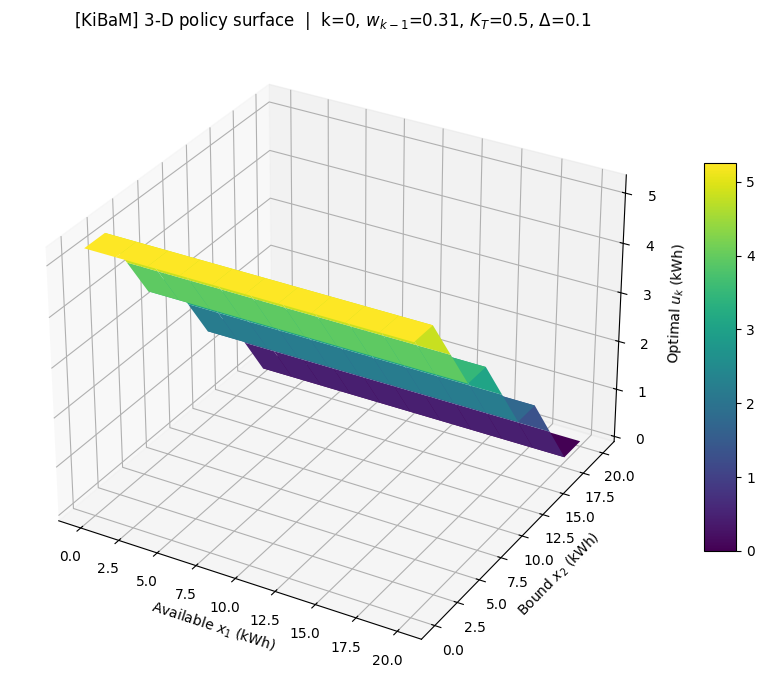

In [ ]:
k_3d   = 0
iw_fix = np.argmin(np.abs(w_grid_kibam - 0.30))

X1, X2 = np.meshgrid(x1_grid, x2_grid, indexing='ij')
U_surf = policy_kibam[k_3d, :, :, iw_fix]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X1, X2, U_surf, cmap='viridis', edgecolor='none')
ax.set_xlabel('Available $x_1$ (kWh)')
ax.set_ylabel('Bound $x_2$ (kWh)')
ax.set_zlabel('Optimal $u_k$ (kWh)')
ax.set_title(f'[KiBaM] 3-D policy surface  |  k={k_3d}, '
             f'$w_{{k-1}}$={w_grid_kibam[iw_fix]:.2f}, '
             f'$K_T$={K_T_rep}, $\\Delta$={Delta_rep}')
fig.colorbar(surf, shrink=0.6, aspect=12)
plt.tight_layout()
plt.show()

## B.13 Sample-Path Simulation — KiBaM

Same idea as Part A, but now the simulator propagates **two** state variables and we plot both tanks plus the total SOC = $x_1 + x_2$.

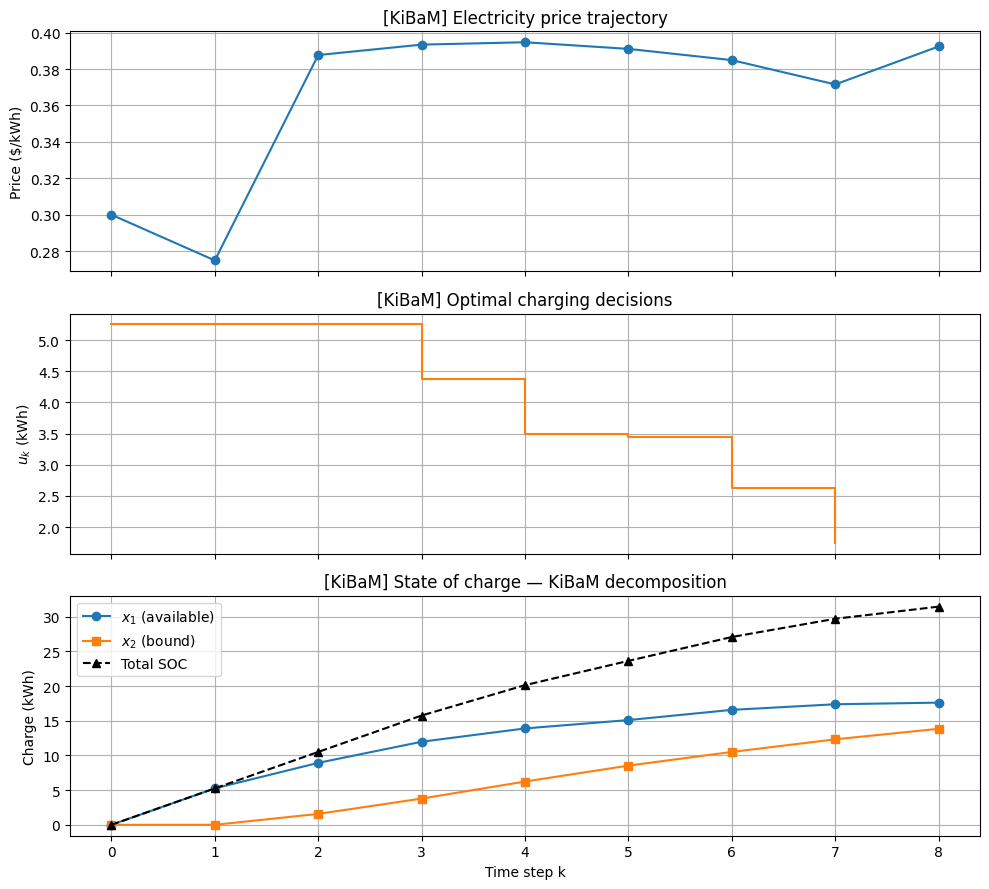

In [ ]:
def simulate_sample_path_kibam(policy, K, Delta, alpha, x1_init, x2_init,
                               w0, seed=42):
    np.random.seed(seed)
    x1, x2, w_prev = x1_init, x2_init, w0
    x1_traj, x2_traj, w_traj, u_traj = [x1], [x2], [w_prev], []

    for k in range(N):
        i1 = np.argmin(np.abs(x1_grid      - x1))
        i2 = np.argmin(np.abs(x2_grid      - x2))
        iw = np.argmin(np.abs(w_grid_kibam - w_prev))

        u = policy[k, i1, i2, iw]
        u = max(0.0, min(u, u_max_physical, alpha * (x1_max - x2)))

        x1, x2 = kibam_step(x1, x2, u, alpha, Delta_t)

        a = max(0.0, 2 * w_prev - K - Delta)
        b = K + Delta
        w_next = np.random.uniform(a, b)

        u_traj.append(u)
        x1_traj.append(x1)
        x2_traj.append(x2)
        w_traj.append(w_next)
        w_prev = w_next

    return (np.array(x1_traj), np.array(x2_traj),
            np.array(w_traj),  np.array(u_traj))


x1_traj_B, x2_traj_B, w_traj_B, u_traj_B = simulate_sample_path_kibam(
    policy_kibam, K, Delta_rep, alpha, x1_0, x2_0, w_initial)

time = np.arange(N + 1)

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(time, w_traj_B, marker='o')
axes[0].set_ylabel('Price ($/kWh)')
axes[0].set_title('[KiBaM] Electricity price trajectory')
axes[0].grid()

axes[1].step(range(N), u_traj_B, where='post', color='tab:orange')
axes[1].set_ylabel('$u_k$ (kWh)')
axes[1].set_title('[KiBaM] Optimal charging decisions')
axes[1].grid()

axes[2].plot(time, x1_traj_B,             marker='o', label='$x_1$ (available)')
axes[2].plot(time, x2_traj_B,             marker='s', label='$x_2$ (bound)')
axes[2].plot(time, x1_traj_B + x2_traj_B, marker='^',
             label='Total SOC', color='black', linestyle='--')
axes[2].set_xlabel('Time step k')
axes[2].set_ylabel('Charge (kWh)')
axes[2].set_title('[KiBaM] State of charge — KiBaM decomposition')
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()

## B.14 Recovery-Effect Demonstration — KiBaM

Three-phase scenario (outside the optimization — this is a physics demo of the model itself):

1. **Charge** for 5 hours at full feasible rate.
2. **Use event** at $k=5$: a chunk is drawn from $x_1$ directly.
3. **Rest** ($u=0$) — observe $x_1$ recover by drawing from $x_2$. The gap $x_1 - x_2$ exponentially decays toward 0.

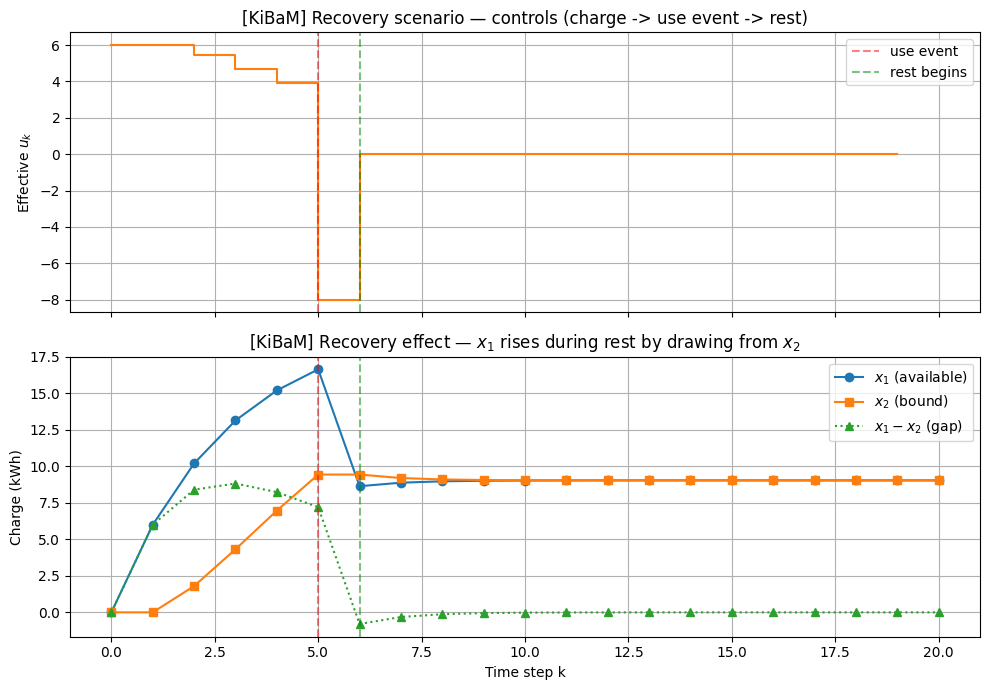

In [ ]:
def simulate_recovery(n_charge=5, n_rest=14, use_amount=8.0, alpha=alpha):
    x1, x2 = 0.0, 0.0
    x1_traj, x2_traj, u_traj = [x1], [x2], []

    # Phase 1: charge as fast as KiBaM allows
    for _ in range(n_charge):
        u = max(0.0, min(u_max_physical, alpha * (x1_max - x2)))
        x1, x2 = kibam_step(x1, x2, u, alpha, Delta_t)
        u_traj.append(u);  x1_traj.append(x1);  x2_traj.append(x2)

    # Phase 2: brief use event — pulls energy directly from x1
    x1 = max(0.0, x1 - use_amount)
    u_traj.append(-use_amount)
    x1_traj.append(x1);  x2_traj.append(x2)

    # Phase 3: rest, watch the tanks equalize
    for _ in range(n_rest):
        u = 0.0
        x1, x2 = kibam_step(x1, x2, u, alpha, Delta_t)
        u_traj.append(u);  x1_traj.append(x1);  x2_traj.append(x2)

    return (np.array(x1_traj), np.array(x2_traj), np.array(u_traj))


x1_rec, x2_rec, u_rec = simulate_recovery()
time_rec = np.arange(len(x1_rec))

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].step(range(len(u_rec)), u_rec, where='post', color='tab:orange')
axes[0].axvline(5, color='red',   linestyle='--', alpha=0.5,
                label='use event')
axes[0].axvline(6, color='green', linestyle='--', alpha=0.5,
                label='rest begins')
axes[0].set_ylabel('Effective $u_k$')
axes[0].set_title('[KiBaM] Recovery scenario — controls (charge -> '
                  'use event -> rest)')
axes[0].legend(); axes[0].grid()

axes[1].plot(time_rec, x1_rec,           marker='o', label='$x_1$ (available)')
axes[1].plot(time_rec, x2_rec,           marker='s', label='$x_2$ (bound)')
axes[1].plot(time_rec, x1_rec - x2_rec,  marker='^',
             label='$x_1 - x_2$ (gap)', linestyle=':')
axes[1].axvline(5, color='red',   linestyle='--', alpha=0.5)
axes[1].axvline(6, color='green', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Time step k')
axes[1].set_ylabel('Charge (kWh)')
axes[1].set_title('[KiBaM] Recovery effect — $x_1$ rises during rest by '
                  'drawing from $x_2$')
axes[1].legend(); axes[1].grid()

plt.tight_layout()
plt.show()

## B.15 Value-Function Surface $J_1(x_1, x_2)$ — KiBaM

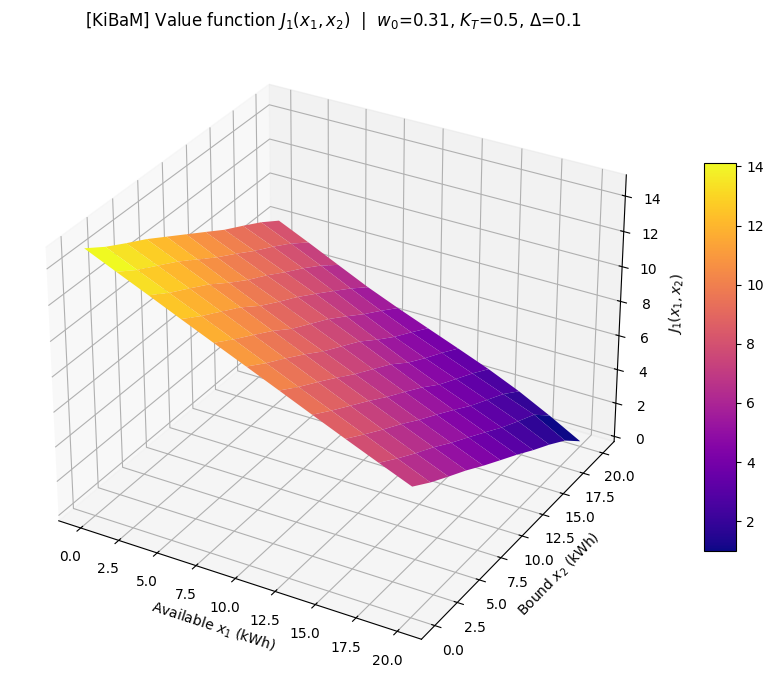

In [ ]:
k_J     = 1
iw_fixJ = np.argmin(np.abs(w_grid_kibam - 0.30))

X1, X2  = np.meshgrid(x1_grid, x2_grid, indexing='ij')
J1_surf = J_kibam[k_J, :, :, iw_fixJ]

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X1, X2, J1_surf, cmap='plasma', edgecolor='none')
ax.set_xlabel('Available $x_1$ (kWh)')
ax.set_ylabel('Bound $x_2$ (kWh)')
ax.set_zlabel('$J_1(x_1, x_2)$')
ax.set_title(f'[KiBaM] Value function $J_1(x_1, x_2)$  |  '
             f'$w_0$={w_grid_kibam[iw_fixJ]:.2f}, '
             f'$K_T$={K_T_rep}, $\\Delta$={Delta_rep}')
fig.colorbar(surf, shrink=0.6, aspect=12)
plt.tight_layout()
plt.show()

# Part C — Comparison & Excel Export

## C.1 Comparison Summary at the Representative $(K_T, \Delta)$

Side-by-side $u_0^*$ and $J_0^*$ for the two models at the same $(K_T, \Delta) = (0.5, 0.10)$. Differences arise solely from the KiBaM dynamics (CC-CV tapering on the upper end of charge).

In [ ]:
u0_ideal, J0_ideal = get_initial(J_ideal, policy_ideal)
u0_kibam, J0_kibam = get_initial_kibam(J_kibam, policy_kibam)

df_compare = pd.DataFrame([
    {'model': 'Ideal',
     'K_T': K_T_rep, 'Delta': Delta_rep,
     'u0_star': u0_ideal, 'J0_star': J0_ideal,
     'initial_state': f'x0={x0}, w_init={w_initial}'},
    {'model': 'KiBaM',
     'K_T': K_T_rep, 'Delta': Delta_rep,
     'u0_star': u0_kibam, 'J0_star': J0_kibam,
     'initial_state': f'x1_0={x1_0}, x2_0={x2_0}, w_init={w_initial}'},
])
print("Comparison at representative case:")
print(df_compare.to_string(index=False))

Comparison at representative case:
model  K_T  Delta  u0_star   J0_star                  initial_state
Ideal  0.5    0.1     7.00 12.639348            x0=40.0, w_init=0.3
KiBaM  0.5    0.1     5.25 14.606258 x1_0=0.0, x2_0=0.0, w_init=0.3


## C.2 Build I/O DataFrames for Excel

We assemble eight DataFrames, one per sheet:

| Sheet                    | Contents                                          |
|--------------------------|---------------------------------------------------|
| `Parameters`             | All input parameters (Ideal vs KiBaM, side-by-side) |
| `Sensitivity_Ideal`      | $4 \times 3 = 12$ rows: $(K_T, \Delta) \to (u_0^*, J_0^*)$ |
| `Sensitivity_KiBaM`      | Same shape for KiBaM                              |
| `Trajectory_Ideal`       | One sample-path: $t, w, u, x$                     |
| `Trajectory_KiBaM`       | One sample-path: $t, w, u, x_1, x_2, \text{total}$ |
| `Recovery_KiBaM`         | Recovery scenario: $t, u, x_1, x_2, \text{gap}$   |
| `Comparison`             | Side-by-side $u_0^*, J_0^*$ at the representative case |
| `J1_Ideal_curves`        | $J_1(x_1, w_0)$ values used in plot A.12          |

In [ ]:
# ---------- (1) Parameters sheet ----------
def fmt_list(L):
    return ', '.join(f'{v:g}' for v in L)

params_rows = [
    # Shared
    ('N',                        N,                       N,                       'steps',  'Number of decision steps'),
    ('Delta_t',                  Delta_t,                 Delta_t,                 'hr',     'Time-step length'),
    ('K',                        K,                       K,                       '$/kWh',  'Price-interval midpoint (mean of w)'),
    ('w_initial',                w_initial,               w_initial,               '$/kWh',  'Initial observed price'),
    ('P_max',                    P_max,                   P_max,                   'kW',     'Charger power cap'),
    ('u_max_physical',           u_max_physical,          u_max_physical,          'kWh',    'P_max * Delta_t'),
    ('K_T_values',               fmt_list(K_T_values),    fmt_list(K_T_values),    '$/kWh',  'Sensitivity sweep over terminal penalty'),
    ('Delta_values',             fmt_list(Delta_values),  fmt_list(Delta_values),  '$/kWh',  'Sensitivity sweep over price spread'),
    ('K_T_rep (representative)', K_T_rep,                 K_T_rep,                 '$/kWh',  'K_T used for plots'),
    ('Delta_rep (representative)', Delta_rep,             Delta_rep,               '$/kWh',  'Delta used for plots'),
    # Battery
    ('E_max',                    E_max,                   x1_max + x2_max,         'kWh',    'Total battery capacity'),
    ('x1_max',                   '-',                     x1_max,                  'kWh',    'KiBaM available-tank max'),
    ('x2_max',                   '-',                     x2_max,                  'kWh',    'KiBaM bound-tank max'),
    ('alpha',                    '-',                     alpha,                   '1/hr',   'KiBaM rate constant'),
    # Initial state
    ('x0 / (x1_0, x2_0)',        f'x0={x0}',
                                   f'x1_0={x1_0}, x2_0={x2_0}',                    'kWh',    'Initial battery state'),
    # Discretization
    ('Nx / (Nx1, Nx2)',          Nx,                      f'Nx1={Nx1}, Nx2={Nx2}', 'pts',    'State-space grid'),
    ('Nw',                       Nw,                      Nw_kibam,                'pts',    'Price-state grid'),
    ('Nu',                       Nu,                      Nu_kibam,                'pts',    'Control grid'),
    ('num_price_quad',           num_price_quad,          num_price_quad_kibam,    'pts',    'Gauss-Legendre quadrature points'),
]

df_params = pd.DataFrame(
    params_rows,
    columns=['parameter', 'ideal_value', 'kibam_value', 'units', 'description'])
print(df_params.to_string(index=False))

                 parameter                     ideal_value                     kibam_value units                             description
                         N                               8                               8 steps                Number of decision steps
                   Delta_t                             1.0                             1.0    hr                        Time-step length
                         K                             0.3                             0.3 $/kWh     Price-interval midpoint (mean of w)
                 w_initial                             0.3                             0.3 $/kWh                  Initial observed price
                     P_max                             7.0                             7.0    kW                       Charger power cap
            u_max_physical                             7.0                             7.0   kWh                         P_max * Delta_t
                K_T_values 0.1, 0.2, 0.3,

In [ ]:
# ---------- (2,3) Sensitivity tables already built above ----------
# df_ideal_sens, df_kibam_sens

# ---------- (4) Trajectory_Ideal ----------
df_traj_ideal = pd.DataFrame({
    't_hr': np.arange(N + 1),
    'price_w':       w_traj_A,
    'control_u':     np.concatenate([u_traj_A, [np.nan]]),
    'remaining_x':   x_traj_A,
})

# ---------- (5) Trajectory_KiBaM ----------
df_traj_kibam = pd.DataFrame({
    't_hr': np.arange(N + 1),
    'price_w':       w_traj_B,
    'control_u':     np.concatenate([u_traj_B, [np.nan]]),
    'x1_available':  x1_traj_B,
    'x2_bound':      x2_traj_B,
    'total_SOC':     x1_traj_B + x2_traj_B,
})

# ---------- (6) Recovery_KiBaM ----------
df_recovery = pd.DataFrame({
    't_step':        np.arange(len(x1_rec)),
    'control_u':     np.concatenate([u_rec, [np.nan]]) if len(u_rec) < len(x1_rec) else u_rec,
    'x1_available':  x1_rec,
    'x2_bound':      x2_rec,
    'gap_x1_minus_x2': x1_rec - x2_rec,
})

# ---------- (7) Comparison already built above (df_compare) ----------

# ---------- (8) J1_Ideal_curves ----------
J1_curves_data = {'x1_kWh': x_grid}
for w0 in [0.2, 0.3, 0.4]:
    iw0 = np.argmin(np.abs(w_grid - w0))
    J1_curves_data[f'J1_w0_{w0}'] = J_ideal[1, :, iw0]
df_J1_curves = pd.DataFrame(J1_curves_data)

print("All DataFrames built:")
for name, df in [('Parameters', df_params),
                 ('Sensitivity_Ideal', df_ideal_sens),
                 ('Sensitivity_KiBaM', df_kibam_sens),
                 ('Trajectory_Ideal',  df_traj_ideal),
                 ('Trajectory_KiBaM',  df_traj_kibam),
                 ('Recovery_KiBaM',    df_recovery),
                 ('Comparison',        df_compare),
                 ('J1_Ideal_curves',   df_J1_curves)]:
    print(f"  {name:22s}  shape={df.shape}")

All DataFrames built:
  Parameters              shape=(19, 5)
  Sensitivity_Ideal       shape=(21, 6)
  Sensitivity_KiBaM       shape=(21, 6)
  Trajectory_Ideal        shape=(9, 4)
  Trajectory_KiBaM        shape=(9, 6)
  Recovery_KiBaM          shape=(21, 5)
  Comparison              shape=(2, 6)
  J1_Ideal_curves         shape=(31, 4)


## C.3 Write Multi-Sheet Excel File

In [ ]:
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df_params.to_excel(      writer, sheet_name='Parameters',         index=False)
    df_ideal_sens.to_excel(  writer, sheet_name='Sensitivity_Ideal',  index=False)
    df_kibam_sens.to_excel(  writer, sheet_name='Sensitivity_KiBaM',  index=False)
    df_traj_ideal.to_excel(  writer, sheet_name='Trajectory_Ideal',   index=False)
    df_traj_kibam.to_excel(  writer, sheet_name='Trajectory_KiBaM',   index=False)
    df_recovery.to_excel(    writer, sheet_name='Recovery_KiBaM',     index=False)
    df_compare.to_excel(     writer, sheet_name='Comparison',         index=False)
    df_J1_curves.to_excel(   writer, sheet_name='J1_Ideal_curves',    index=False)

print(f"\nWrote: {os.path.abspath(excel_path)}")
print(f"File size: {os.path.getsize(excel_path):,} bytes")


Wrote: c:\Users\dhrub\Downloads\DP_EV_Combined_Results.xlsx
File size: 14,283 bytes


## C.4 Notebook Summary

What this combined notebook produced:

- **Part A (Ideal):** sensitivity table over $4 \times 3 = 12$ parameter pairs, three policy heatmaps, sample-path trajectory, $J_1$ curves, and a $\Delta \to 0$ verification run.
- **Part B (KiBaM):** sensitivity table over the same 12 pairs, three sliced policy heatmaps, a 3-D policy surface, sample-path trajectory, recovery-effect demonstration, and a 3-D $J_1$ surface.
- **Part C:** comparison table at the representative case and an 8-sheet Excel export (`DP_EV_Combined_Results.xlsx`).

To re-run for different parameters, edit the values in **A.2** (ideal) and **B.2** (KiBaM) and execute *Run All*. The Excel file will be overwritten with fresh data.